In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import pickle
import sys
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from utils import preprocess_xgboost, get_model_metrics, get_model_figs
import numpy as np
from matplotlib.colors import Normalize
from sklearn.metrics import root_mean_squared_error

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from atow_estimation.paths import PROCESSED_DATA_DIR

c:\Users\jaguevara\AppData\Local\anaconda3\envs\TFM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_m1 = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m1.csv"))
data_m2 = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2.csv"))
data_H = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_H.csv"))
data_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_M.csv"))
data_m1_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m1_M.csv"))
data_m1_H = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m1_H.csv"))
data_m2_M = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2_M.csv"))
data_m2_H = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2_H.csv"))

### Model 1 Medium Wake

In [3]:
X_train, X_test, y_train, y_test = preprocess_xgboost(data_m1_M)

In [4]:
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'random_state': 42,
        'n_estimators': 10_000,  
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-3, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'n_jobs': -1,
        'eval_metric': 'rmse',
        'tree_method': 'hist',
        'early_stopping_rounds': 40
    }
    
    model = XGBRegressor(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    preds = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    trial.set_user_attr("best_iteration", model.best_iteration)
    
    return rmse

In [5]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Display the best hyperparameters found
print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
print(f"  Value (RMSE): {study.best_trial.value}")
print(f"  Params: {study.best_trial.params}")
print(f"  Best Iteration (0-indexed): {study.best_trial.user_attrs['best_iteration']}")

[I 2025-05-25 22:53:36,012] A new study created in memory with name: no-name-6b96a031-d72c-43e0-8cbf-8f7256648945
[I 2025-05-25 22:55:34,437] Trial 0 finished with value: 1449.7731292355552 and parameters: {'learning_rate': 0.02522785408945444, 'max_depth': 15, 'min_child_weight': 4, 'gamma': 0.20623442926063842, 'subsample': 0.9792000320843899, 'colsample_bytree': 0.7133512023472548, 'reg_alpha': 0.0003918019427641734, 'reg_lambda': 0.0008572121971606667}. Best is trial 0 with value: 1449.7731292355552.
[I 2025-05-25 22:55:52,085] Trial 1 finished with value: 1395.2462568408625 and parameters: {'learning_rate': 0.0496379868694586, 'max_depth': 3, 'min_child_weight': 10, 'gamma': 0.1453755264714132, 'subsample': 0.584151343368011, 'colsample_bytree': 0.5860749151717235, 'reg_alpha': 0.002876372189347887, 'reg_lambda': 0.016217231400978648}. Best is trial 1 with value: 1395.2462568408625.
[I 2025-05-25 22:57:10,249] Trial 2 finished with value: 1345.780327641905 and parameters: {'learni


--- Optuna Study Results ---
Number of finished trials: 10
Best trial:
  Value (RMSE): 1343.7809597575813
  Params: {'learning_rate': 0.0029005248594910983, 'max_depth': 11, 'min_child_weight': 7, 'gamma': 0.04992535538018538, 'subsample': 0.6056966226633311, 'colsample_bytree': 0.5545891075229978, 'reg_alpha': 0.09895391281291349, 'reg_lambda': 0.00019480741443132738}
  Best Iteration (0-indexed): 6366


In [6]:
print("\n--- Retrieving the Best Model ---")
best_trial = study.best_trial
best_params = best_trial.params.copy()

optimal_n_estimators = best_trial.user_attrs.get('best_iteration', best_params.get('n_estimators', 100))
if 'n_estimators' in best_params: 
    del best_params['n_estimators']

print(f"Training final model with optimal n_estimators: {optimal_n_estimators}")
final_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=optimal_n_estimators, 
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    min_child_weight=best_params['min_child_weight'],
    gamma=best_params['gamma'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    n_jobs=-1,
    eval_metric='rmse', 
    tree_method='hist'  
)

final_model.fit(X_train, y_train, verbose=False) 


--- Retrieving the Best Model ---
Training final model with optimal n_estimators: 6366


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5545891075229978, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.04992535538018538, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.0029005248594910983,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=11, max_leaves=None,
             min_child_weight=7, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=6366, n_jobs=-1,
             num_parallel_tree=None, ...)

In [8]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 929.24
Root Mean Squared Error: 1343.78
R^2 Score: 0.9667


In [9]:
with open('../models/XGBoost_m1_M.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

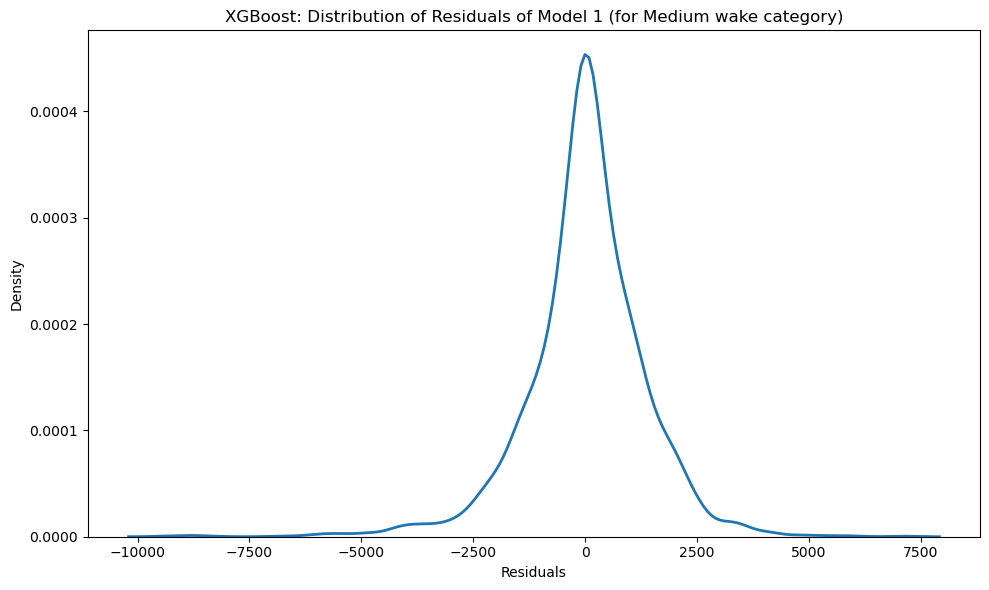

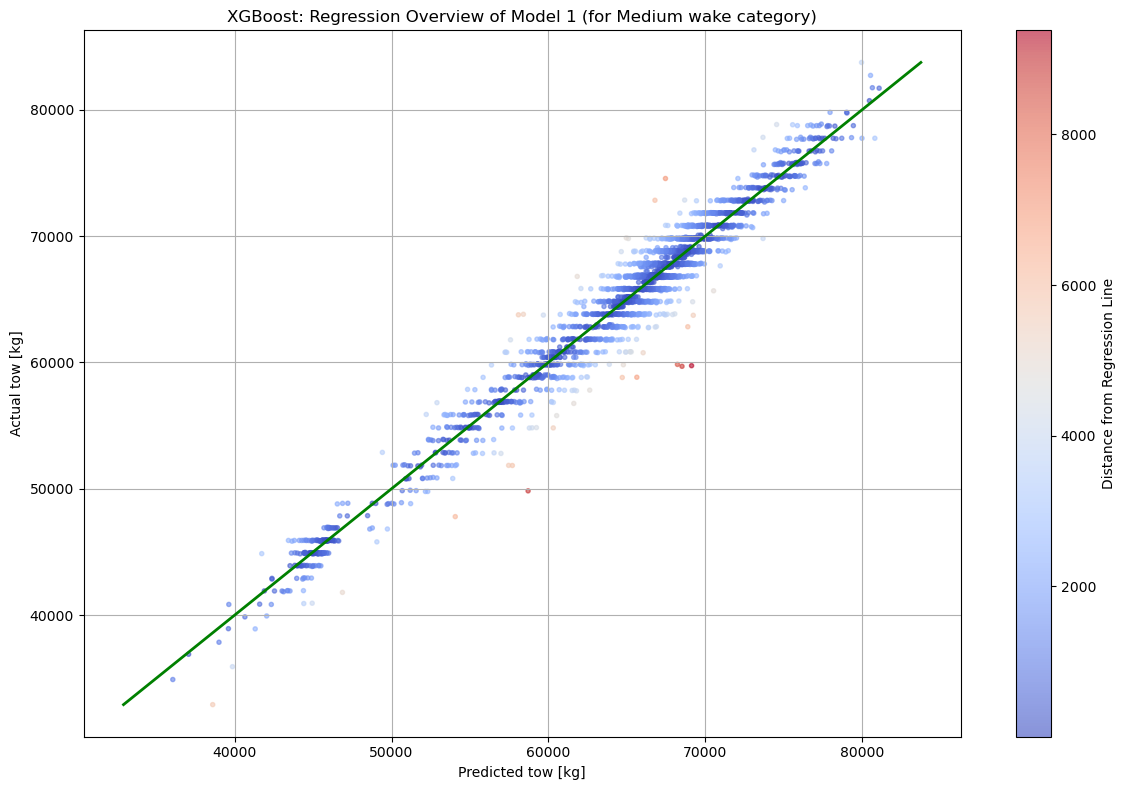

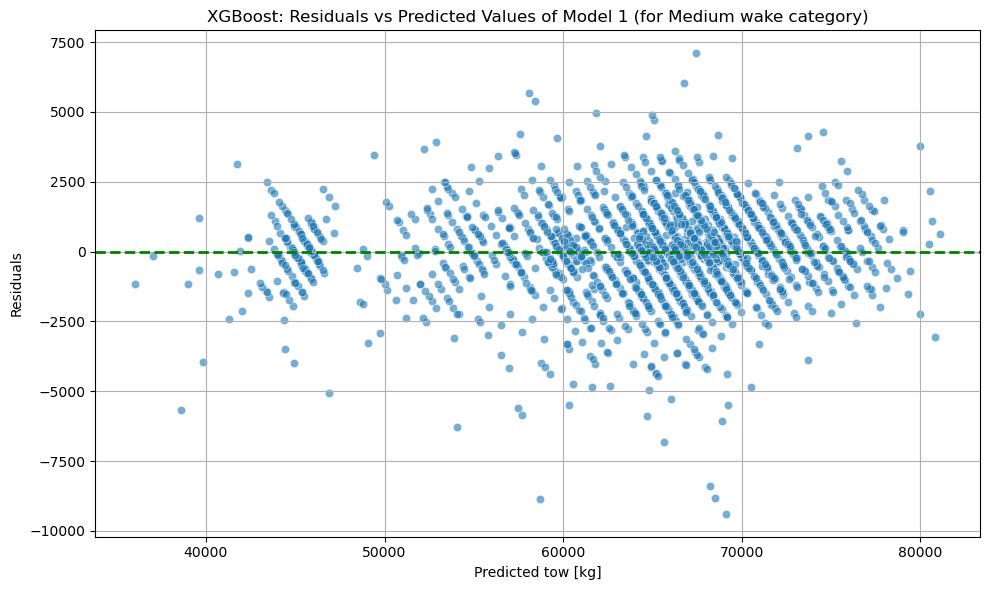

In [10]:
residuals = y_test - y_pred

title1 = "XGBoost: Distribution of Residuals of Model 1 (for Medium wake category)"
title2 = "XGBoost: Regression Overview of Model 1 (for Medium wake category)"
title3 = "XGBoost: Residuals vs Predicted Values of Model 1 (for Medium wake category)"

path1 = "../reports/figures/m1/M_wake/xgboost_residuals_distribution.png"
path2 = "../reports/figures/m1/M_wake/xgboost_scatter.png"
path3 = "../reports/figures/m1/M_wake/xgboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### Model 1 Heavy Wake

In [11]:
X_train, X_test, y_train, y_test = preprocess_xgboost(data_m1_H)

In [13]:
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'random_state': 42,
        'n_estimators': 10_000,  
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-3, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'n_jobs': -1,
        'eval_metric': 'rmse',
        'tree_method': 'hist',
        'early_stopping_rounds': 40
    }
    
    model = XGBRegressor(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    preds = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    trial.set_user_attr("best_iteration", model.best_iteration)
    
    return rmse

In [14]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Display the best hyperparameters found
print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
print(f"  Value (RMSE): {study.best_trial.value}")
print(f"  Params: {study.best_trial.params}")
print(f"  Best Iteration (0-indexed): {study.best_trial.user_attrs['best_iteration']}")

[I 2025-05-25 23:59:52,433] A new study created in memory with name: no-name-a586a65e-c3c7-4ed4-8449-b297b2bdde2a
[I 2025-05-26 00:00:37,796] Trial 0 finished with value: 5877.336954194236 and parameters: {'learning_rate': 0.002346235359685597, 'max_depth': 6, 'min_child_weight': 1, 'gamma': 0.8492066055007754, 'subsample': 0.8787018618695723, 'colsample_bytree': 0.8780753389759555, 'reg_alpha': 0.015110042561664396, 'reg_lambda': 0.030664239896816013}. Best is trial 0 with value: 5877.336954194236.
[I 2025-05-26 00:00:49,231] Trial 1 finished with value: 5975.050923651425 and parameters: {'learning_rate': 0.017517075926151208, 'max_depth': 6, 'min_child_weight': 2, 'gamma': 0.0018910975997914973, 'subsample': 0.9574649985891437, 'colsample_bytree': 0.9432200893818621, 'reg_alpha': 0.03486176323071222, 'reg_lambda': 0.00017116730434871364}. Best is trial 0 with value: 5877.336954194236.
[I 2025-05-26 00:01:32,705] Trial 2 finished with value: 5542.523476020564 and parameters: {'learnin


--- Optuna Study Results ---
Number of finished trials: 10
Best trial:
  Value (RMSE): 5517.621236128602
  Params: {'learning_rate': 0.01985565058681618, 'max_depth': 9, 'min_child_weight': 10, 'gamma': 0.006212825081201798, 'subsample': 0.8900509314876617, 'colsample_bytree': 0.4637357874491569, 'reg_alpha': 0.572392366869915, 'reg_lambda': 0.017675635083048247}
  Best Iteration (0-indexed): 680


In [15]:
print("\n--- Retrieving the Best Model ---")
best_trial = study.best_trial
best_params = best_trial.params.copy()

optimal_n_estimators = best_trial.user_attrs.get('best_iteration', best_params.get('n_estimators', 100))
if 'n_estimators' in best_params: 
    del best_params['n_estimators']

print(f"Training final model with optimal n_estimators: {optimal_n_estimators}")
final_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=optimal_n_estimators, 
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    min_child_weight=best_params['min_child_weight'],
    gamma=best_params['gamma'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    n_jobs=-1,
    eval_metric='rmse', 
    tree_method='hist'  
)

final_model.fit(X_train, y_train, verbose=False) 


--- Retrieving the Best Model ---
Training final model with optimal n_estimators: 680


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.4637357874491569, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.006212825081201798, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01985565058681618,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=680, n_jobs=-1,
             num_parallel_tree=None, ...)

In [16]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 3927.12
Root Mean Squared Error: 5517.91
R^2 Score: 0.9269


In [17]:
with open('../models/XGBoost_m1_H.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

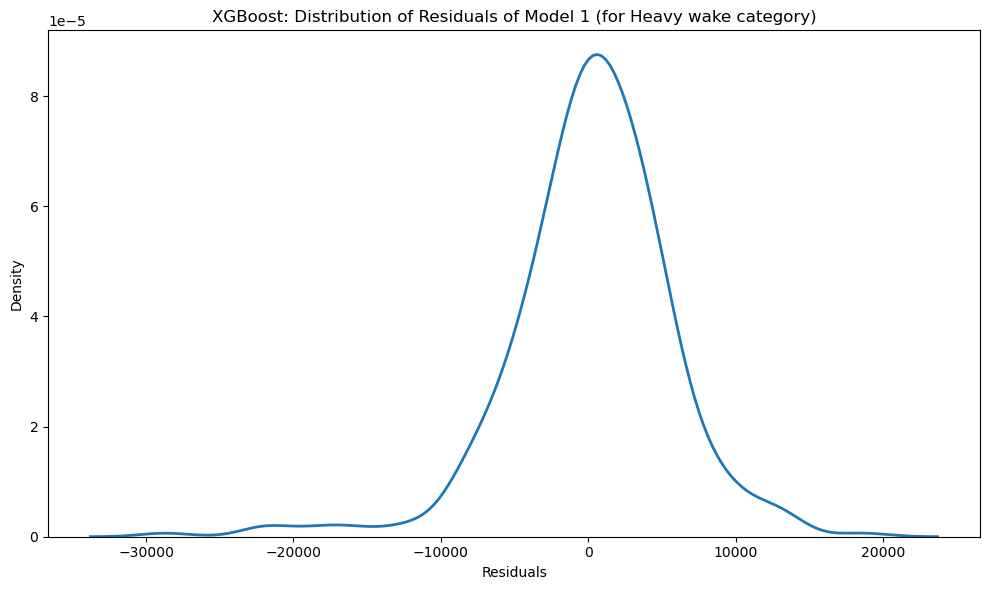

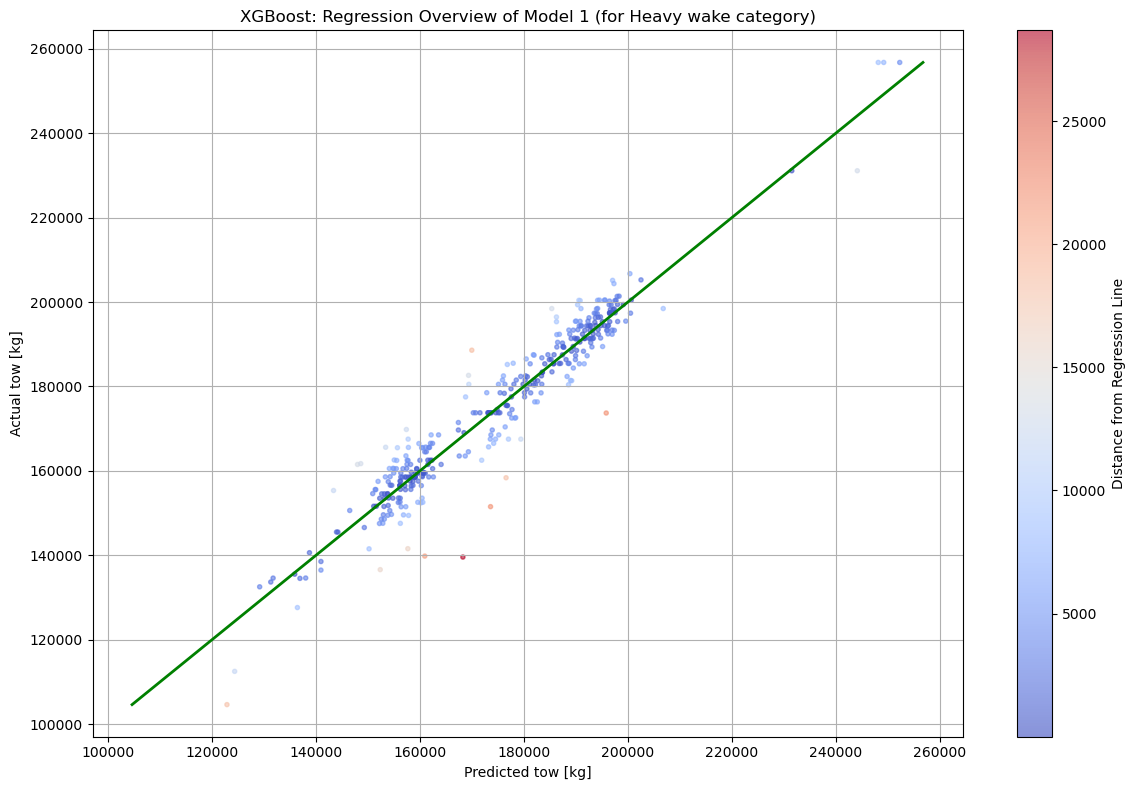

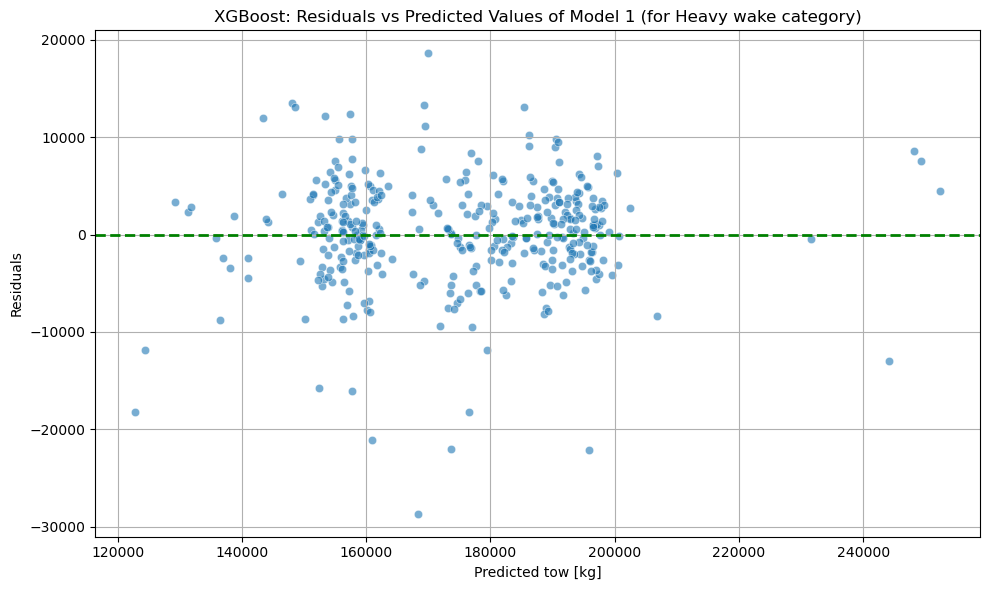

In [18]:
residuals = y_test - y_pred

title1 = "XGBoost: Distribution of Residuals of Model 1 (for Heavy wake category)"
title2 = "XGBoost: Regression Overview of Model 1 (for Heavy wake category)"
title3 = "XGBoost: Residuals vs Predicted Values of Model 1 (for Heavy wake category)"

path1 = "../reports/figures/m1/H_wake/xgboost_residuals_distribution.png"
path2 = "../reports/figures/m1/H_wake/xgboost_scatter.png"
path3 = "../reports/figures/m1/H_wake/xgboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### Model 2 Medium Wake

In [19]:
X_train, X_test, y_train, y_test = preprocess_xgboost(data_m2_M)

In [20]:
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'random_state': 42,
        'n_estimators': 10_000,  
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-3, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'n_jobs': -1,
        'eval_metric': 'rmse',
        'tree_method': 'hist',
        'early_stopping_rounds': 40
    }
    
    model = XGBRegressor(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    preds = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    trial.set_user_attr("best_iteration", model.best_iteration)
    
    return rmse

In [21]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Display the best hyperparameters found
print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
print(f"  Value (RMSE): {study.best_trial.value}")
print(f"  Params: {study.best_trial.params}")
print(f"  Best Iteration (0-indexed): {study.best_trial.user_attrs['best_iteration']}")

[I 2025-05-26 00:11:10,689] A new study created in memory with name: no-name-1fda4203-3438-440a-9e2b-90e18a1624c9
[I 2025-05-26 00:12:12,987] Trial 0 finished with value: 1918.6906470488284 and parameters: {'learning_rate': 0.0017948311576955207, 'max_depth': 4, 'min_child_weight': 10, 'gamma': 0.27056282496932305, 'subsample': 0.6771919585275903, 'colsample_bytree': 0.54791273055161, 'reg_alpha': 0.13690353622446813, 'reg_lambda': 0.0318826856236504}. Best is trial 0 with value: 1918.6906470488284.
[I 2025-05-26 00:13:27,390] Trial 1 finished with value: 1860.5342583592076 and parameters: {'learning_rate': 0.001476599714660758, 'max_depth': 5, 'min_child_weight': 10, 'gamma': 0.17132675790976928, 'subsample': 0.6008897971196703, 'colsample_bytree': 0.5274588878775242, 'reg_alpha': 0.019789570987154562, 'reg_lambda': 0.5738975302616356}. Best is trial 1 with value: 1860.5342583592076.
[I 2025-05-26 00:13:33,055] Trial 2 finished with value: 1789.0767349401503 and parameters: {'learning


--- Optuna Study Results ---
Number of finished trials: 10
Best trial:
  Value (RMSE): 1694.8375664077817
  Params: {'learning_rate': 0.00786520762349115, 'max_depth': 11, 'min_child_weight': 10, 'gamma': 0.029419876022454782, 'subsample': 0.9797466140074996, 'colsample_bytree': 0.6164501646892294, 'reg_alpha': 0.018640495251537808, 'reg_lambda': 0.2785306095101894}
  Best Iteration (0-indexed): 2503


In [22]:
print("\n--- Retrieving the Best Model ---")
best_trial = study.best_trial
best_params = best_trial.params.copy()

optimal_n_estimators = best_trial.user_attrs.get('best_iteration', best_params.get('n_estimators', 100))
if 'n_estimators' in best_params: 
    del best_params['n_estimators']

print(f"Training final model with optimal n_estimators: {optimal_n_estimators}")
final_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=optimal_n_estimators, 
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    min_child_weight=best_params['min_child_weight'],
    gamma=best_params['gamma'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    n_jobs=-1,
    eval_metric='rmse', 
    tree_method='hist'  
)

final_model.fit(X_train, y_train, verbose=False) 


--- Retrieving the Best Model ---
Training final model with optimal n_estimators: 2503


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6164501646892294, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.029419876022454782, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.00786520762349115,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=11, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=2503, n_jobs=-1,
             num_parallel_tree=None, ...)

In [23]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 1104.48
Root Mean Squared Error: 1694.84
R^2 Score: 0.9568


In [24]:
with open('../models/XGBoost_m2_M.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

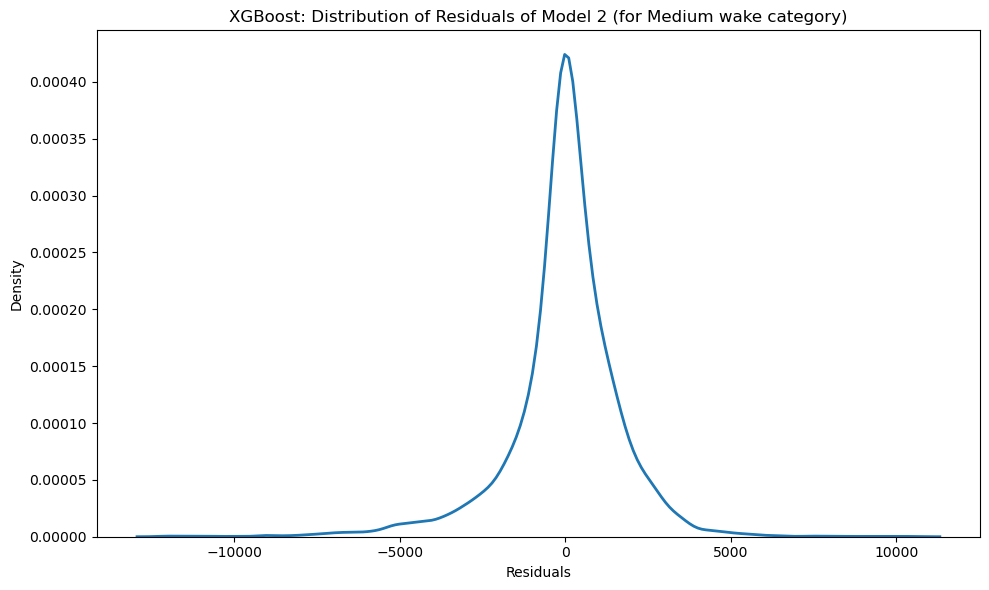

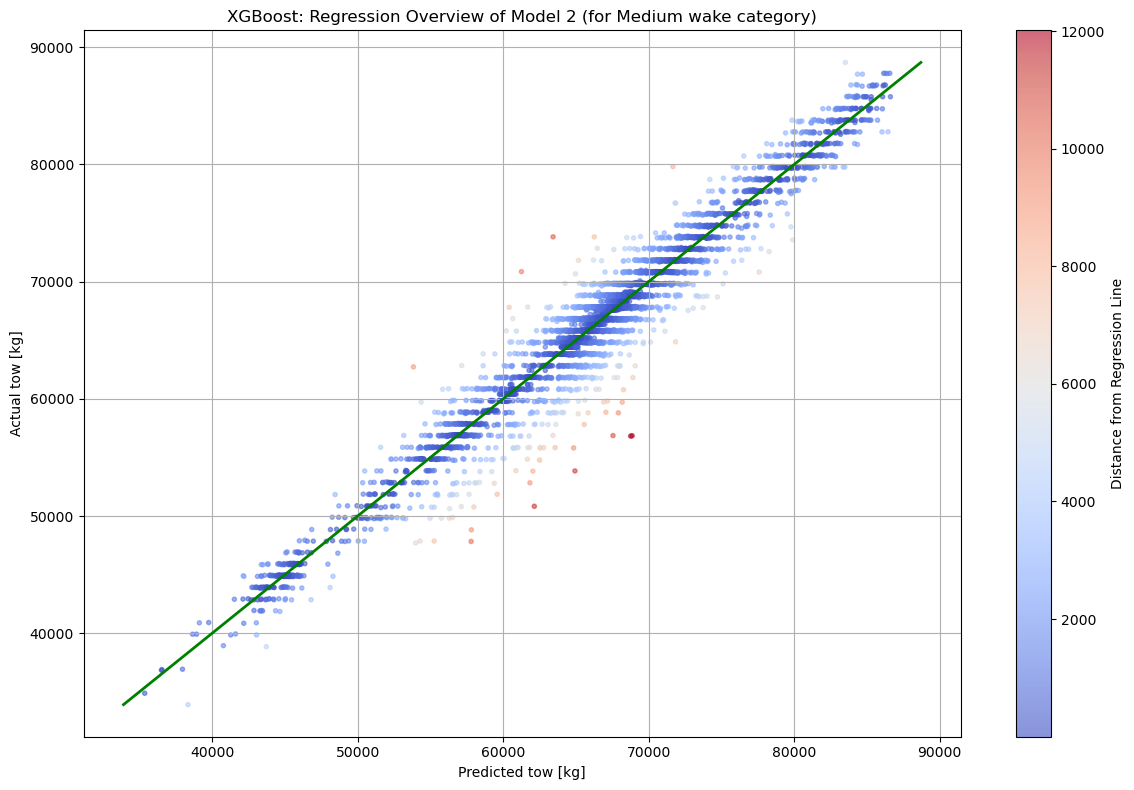

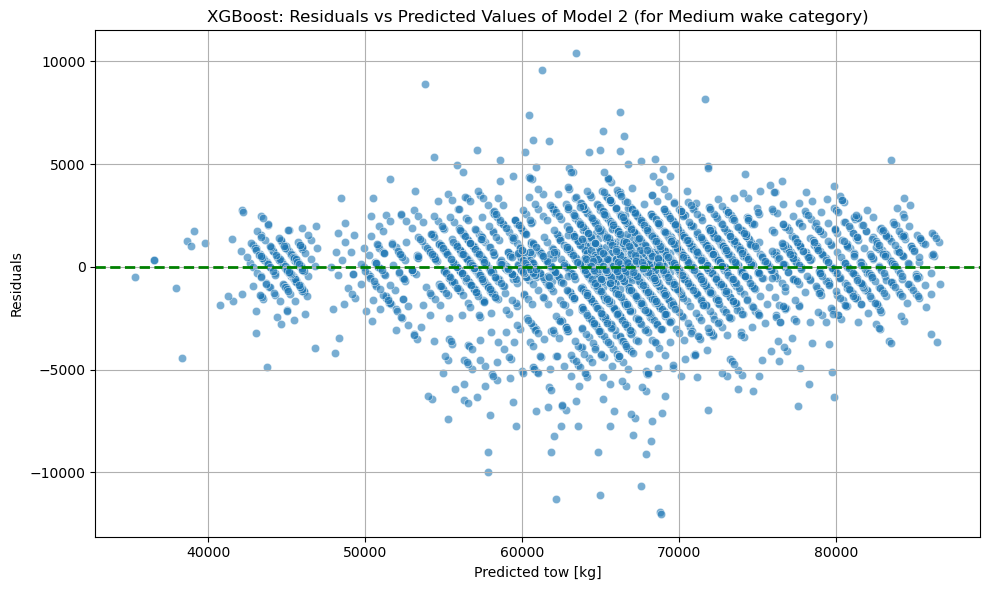

In [25]:
residuals = y_test - y_pred

title1 = "XGBoost: Distribution of Residuals of Model 2 (for Medium wake category)"
title2 = "XGBoost: Regression Overview of Model 2 (for Medium wake category)"
title3 = "XGBoost: Residuals vs Predicted Values of Model 2 (for Medium wake category)"

path1 = "../reports/figures/m2/M_wake/xgboost_residuals_distribution.png"
path2 = "../reports/figures/m2/M_wake/xgboost_scatter.png"
path3 = "../reports/figures/m2/M_wake/xgboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### Model 2 Heavy Wake

In [26]:
X_train, X_test, y_train, y_test = preprocess_xgboost(data_m2_H)

In [27]:
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'random_state': 42,
        'n_estimators': 10_000,  
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-3, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'n_jobs': -1,
        'eval_metric': 'rmse',
        'tree_method': 'hist',
        'early_stopping_rounds': 40
    }
    
    model = XGBRegressor(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    preds = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    trial.set_user_attr("best_iteration", model.best_iteration)
    
    return rmse

In [28]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Display the best hyperparameters found
print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
print(f"  Value (RMSE): {study.best_trial.value}")
print(f"  Params: {study.best_trial.params}")
print(f"  Best Iteration (0-indexed): {study.best_trial.user_attrs['best_iteration']}")

[I 2025-05-26 00:34:25,505] A new study created in memory with name: no-name-d8ea8eb5-f99c-4934-b60f-14d51772db22
[I 2025-05-26 00:35:38,416] Trial 0 finished with value: 5354.783104244122 and parameters: {'learning_rate': 0.0013121635588627869, 'max_depth': 12, 'min_child_weight': 6, 'gamma': 0.47175423389243754, 'subsample': 0.5562290553301465, 'colsample_bytree': 0.9270897618556709, 'reg_alpha': 0.0005205693058364109, 'reg_lambda': 0.0014621922341460773}. Best is trial 0 with value: 5354.783104244122.
[I 2025-05-26 00:36:33,398] Trial 1 finished with value: 5397.112655054711 and parameters: {'learning_rate': 0.003942618723090939, 'max_depth': 15, 'min_child_weight': 7, 'gamma': 0.060132591108591114, 'subsample': 0.9699683035854108, 'colsample_bytree': 0.8707532595557212, 'reg_alpha': 0.0001832000340378964, 'reg_lambda': 0.000646003872351065}. Best is trial 0 with value: 5354.783104244122.
[I 2025-05-26 00:36:51,919] Trial 2 finished with value: 5357.2768393682145 and parameters: {'l


--- Optuna Study Results ---
Number of finished trials: 10
Best trial:
  Value (RMSE): 5199.00435534033
  Params: {'learning_rate': 0.022255932722386358, 'max_depth': 7, 'min_child_weight': 5, 'gamma': 0.006039372567202415, 'subsample': 0.6023419397276619, 'colsample_bytree': 0.824324909235147, 'reg_alpha': 0.008869518750260756, 'reg_lambda': 0.11227236967971783}
  Best Iteration (0-indexed): 676


In [29]:
print("\n--- Retrieving the Best Model ---")
best_trial = study.best_trial
best_params = best_trial.params.copy()

optimal_n_estimators = best_trial.user_attrs.get('best_iteration', best_params.get('n_estimators', 100))
if 'n_estimators' in best_params: 
    del best_params['n_estimators']

print(f"Training final model with optimal n_estimators: {optimal_n_estimators}")
final_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=optimal_n_estimators, 
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    min_child_weight=best_params['min_child_weight'],
    gamma=best_params['gamma'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    n_jobs=-1,
    eval_metric='rmse', 
    tree_method='hist'  
)

final_model.fit(X_train, y_train, verbose=False) 


--- Retrieving the Best Model ---
Training final model with optimal n_estimators: 676


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.824324909235147, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.006039372567202415, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.022255932722386358,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=676, n_jobs=-1,
             num_parallel_tree=None, ...)

In [30]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 3812.92
Root Mean Squared Error: 5199.82
R^2 Score: 0.9665


In [31]:
with open('../models/XGBoost_m2_H.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

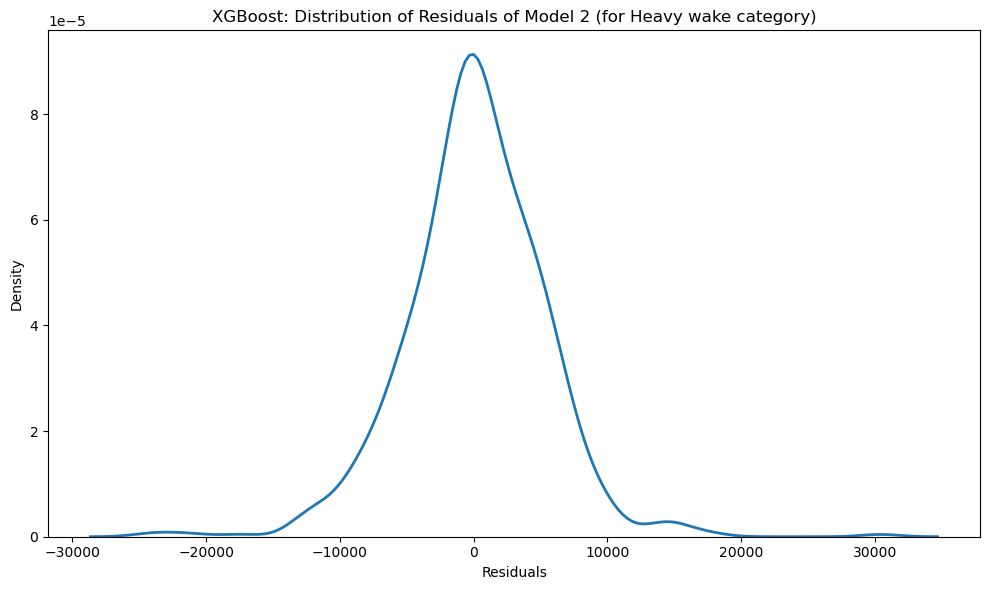

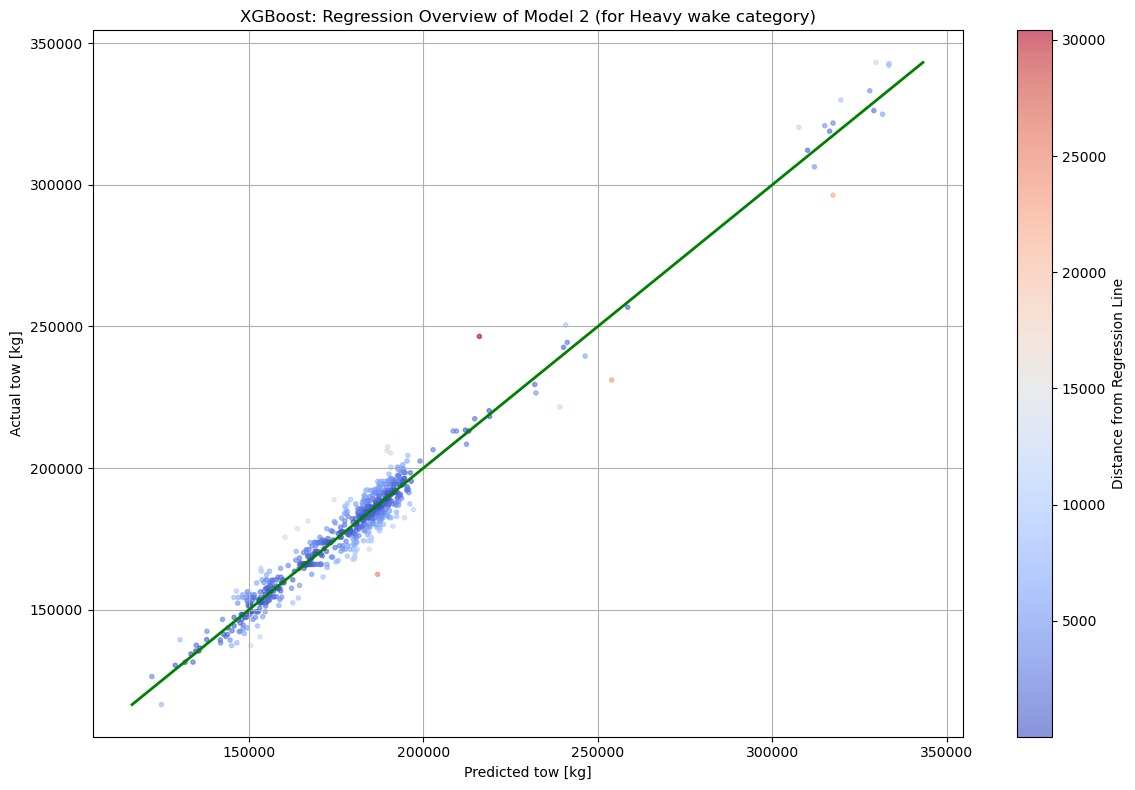

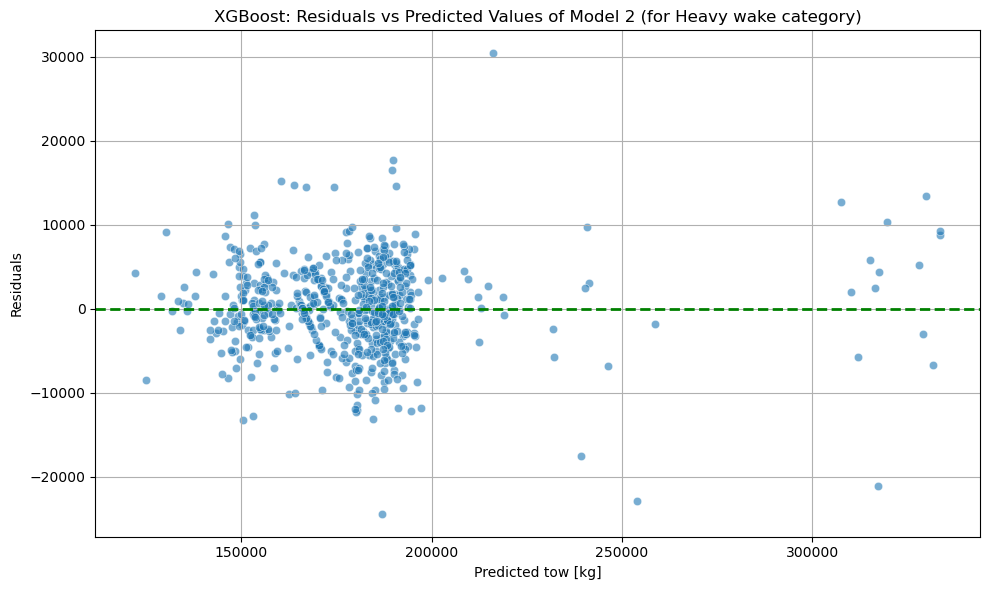

In [32]:
residuals = y_test - y_pred

title1 = "XGBoost: Distribution of Residuals of Model 2 (for Heavy wake category)"
title2 = "XGBoost: Regression Overview of Model 2 (for Heavy wake category)"
title3 = "XGBoost: Residuals vs Predicted Values of Model 2 (for Heavy wake category)"

path1 = "../reports/figures/m2/H_wake/xgboost_residuals_distribution.png"
path2 = "../reports/figures/m2/H_wake/xgboost_scatter.png"
path3 = "../reports/figures/m2/H_wake/xgboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### m1 + m2 (for M wake category)

In [33]:
X_train, X_test, y_train, y_test = preprocess_xgboost(data_M)

In [34]:
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'random_state': 42,
        'n_estimators': 10_000,  
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-3, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'n_jobs': -1,
        'eval_metric': 'rmse',
        'tree_method': 'hist',
        'early_stopping_rounds': 40
    }
    
    model = XGBRegressor(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    preds = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    trial.set_user_attr("best_iteration", model.best_iteration)
    
    return rmse

In [35]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Display the best hyperparameters found
print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
print(f"  Value (RMSE): {study.best_trial.value}")
print(f"  Params: {study.best_trial.params}")
print(f"  Best Iteration (0-indexed): {study.best_trial.user_attrs['best_iteration']}")

[I 2025-05-26 00:40:46,977] A new study created in memory with name: no-name-5f4d03dc-1610-42de-a302-47ba8c9b1d22
[I 2025-05-26 00:41:53,252] Trial 0 finished with value: 1674.7097233091717 and parameters: {'learning_rate': 0.02864793161714278, 'max_depth': 3, 'min_child_weight': 10, 'gamma': 0.031413466092592275, 'subsample': 0.612807451617138, 'colsample_bytree': 0.5873279744564508, 'reg_alpha': 0.00157273925518378, 'reg_lambda': 0.000845814711324414}. Best is trial 0 with value: 1674.7097233091717.
[I 2025-05-26 00:42:47,516] Trial 1 finished with value: 1572.2876593498995 and parameters: {'learning_rate': 0.024223418835238895, 'max_depth': 11, 'min_child_weight': 10, 'gamma': 0.4541190599291395, 'subsample': 0.7285521962628714, 'colsample_bytree': 0.8357765100985879, 'reg_alpha': 0.0004853830146385185, 'reg_lambda': 0.00021261162884968305}. Best is trial 1 with value: 1572.2876593498995.
[I 2025-05-26 00:43:33,799] Trial 2 finished with value: 1603.2264302066283 and parameters: {'l


--- Optuna Study Results ---
Number of finished trials: 10
Best trial:
  Value (RMSE): 1566.7468472738326
  Params: {'learning_rate': 0.001390227336297934, 'max_depth': 14, 'min_child_weight': 10, 'gamma': 0.0031915938536987397, 'subsample': 0.7749423925981413, 'colsample_bytree': 0.527880988373837, 'reg_alpha': 0.0007341145863995976, 'reg_lambda': 0.30760426645600236}
  Best Iteration (0-indexed): 9999


In [36]:
print("\n--- Retrieving the Best Model ---")
best_trial = study.best_trial
best_params = best_trial.params.copy()

optimal_n_estimators = best_trial.user_attrs.get('best_iteration', best_params.get('n_estimators', 100))
if 'n_estimators' in best_params: 
    del best_params['n_estimators']

print(f"Training final model with optimal n_estimators: {optimal_n_estimators}")
final_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=optimal_n_estimators, 
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    min_child_weight=best_params['min_child_weight'],
    gamma=best_params['gamma'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    n_jobs=-1,
    eval_metric='rmse', 
    tree_method='hist'  
)

final_model.fit(X_train, y_train, verbose=False) 


--- Retrieving the Best Model ---
Training final model with optimal n_estimators: 9999


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.527880988373837, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.0031915938536987397, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.001390227336297934, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=14, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=9999, n_jobs=-1,
             num_parallel_tree=None, ...)

In [37]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 1022.11
Root Mean Squared Error: 1566.75
R^2 Score: 0.9609


In [38]:
with open('../models/XGBoost_m1+m2_M.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

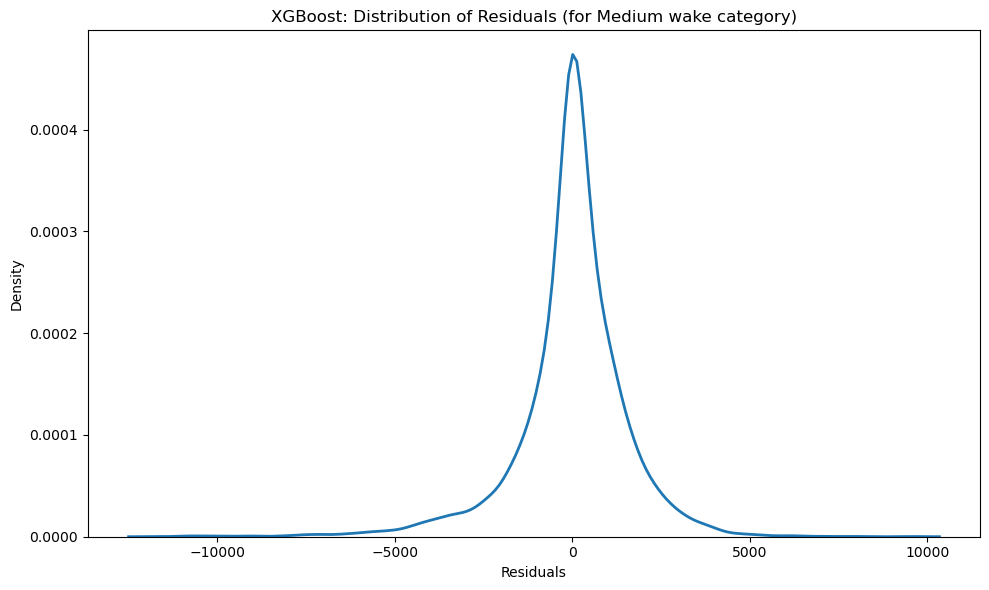

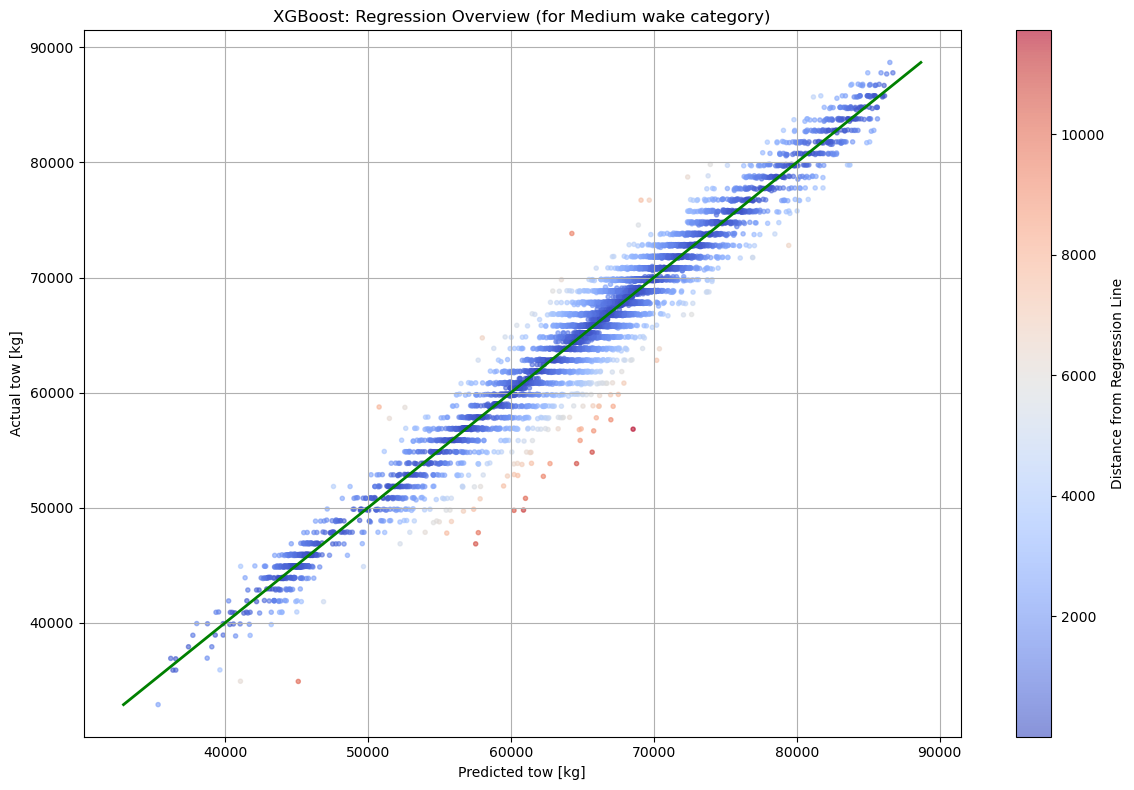

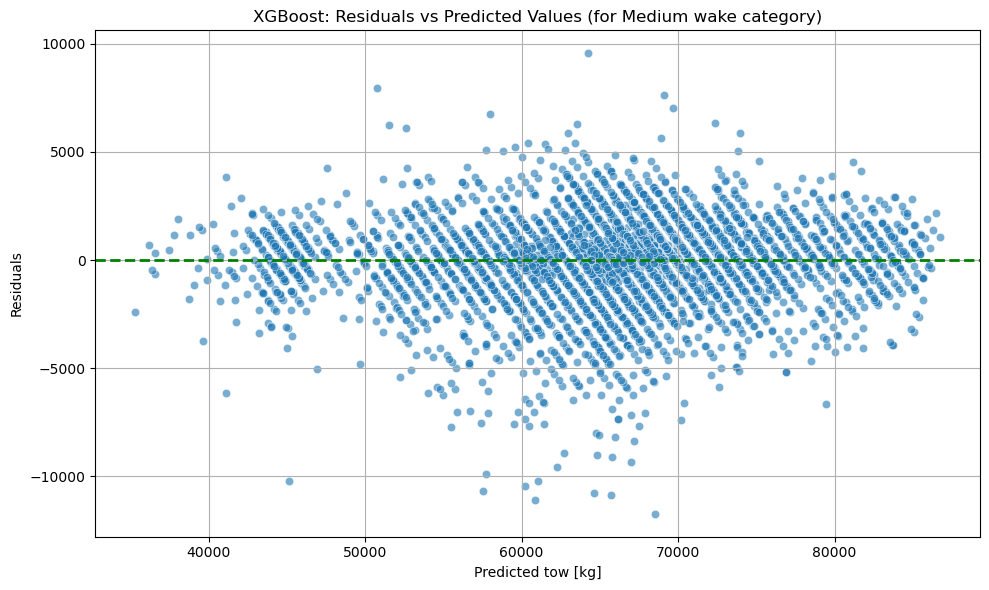

In [39]:
residuals = y_test - y_pred

title1 = "XGBoost: Distribution of Residuals (for Medium wake category)"
title2 = "XGBoost: Regression Overview (for Medium wake category)"
title3 = "XGBoost: Residuals vs Predicted Values (for Medium wake category)"

path1 = "../reports/figures/M/xgboost_residuals_distribution.png"
path2 = "../reports/figures/M/xgboost_scatter.png"
path3 = "../reports/figures/M/xgboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)

### m1 + m2 (for H wake category)

In [40]:
X_train, X_test, y_train, y_test = preprocess_xgboost(data_H)

In [41]:
def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'random_state': 42,
        'n_estimators': 10_000,  
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-3, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'n_jobs': -1,
        'eval_metric': 'rmse',
        'tree_method': 'hist',
        'early_stopping_rounds': 40
    }
    
    model = XGBRegressor(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    preds = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    trial.set_user_attr("best_iteration", model.best_iteration)
    
    return rmse

In [42]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Display the best hyperparameters found
print("\n--- Optuna Study Results ---")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
print(f"  Value (RMSE): {study.best_trial.value}")
print(f"  Params: {study.best_trial.params}")
print(f"  Best Iteration (0-indexed): {study.best_trial.user_attrs['best_iteration']}")

[I 2025-05-26 01:14:10,450] A new study created in memory with name: no-name-49eb9a9f-4070-4502-8c63-51a913e28548
[I 2025-05-26 01:15:36,835] Trial 0 finished with value: 5131.820254192875 and parameters: {'learning_rate': 0.0017937785957074625, 'max_depth': 13, 'min_child_weight': 6, 'gamma': 0.2339700721811314, 'subsample': 0.8402706571545051, 'colsample_bytree': 0.6963157164514535, 'reg_alpha': 0.0033129814491057665, 'reg_lambda': 0.15643308688875632}. Best is trial 0 with value: 5131.820254192875.
[I 2025-05-26 01:15:40,174] Trial 1 finished with value: 5237.748588386042 and parameters: {'learning_rate': 0.028470514380550326, 'max_depth': 3, 'min_child_weight': 9, 'gamma': 0.01403150429585596, 'subsample': 0.5588805835445327, 'colsample_bytree': 0.7168508031209342, 'reg_alpha': 0.016318082851502404, 'reg_lambda': 0.0011124612713475264}. Best is trial 0 with value: 5131.820254192875.
[I 2025-05-26 01:16:57,697] Trial 2 finished with value: 5020.711540003937 and parameters: {'learnin


--- Optuna Study Results ---
Number of finished trials: 10
Best trial:
  Value (RMSE): 4955.965806776883
  Params: {'learning_rate': 0.005814781103853738, 'max_depth': 10, 'min_child_weight': 1, 'gamma': 0.6962099769836066, 'subsample': 0.7630911466771269, 'colsample_bytree': 0.6954290129271512, 'reg_alpha': 0.440465424667652, 'reg_lambda': 0.3502995074875314}
  Best Iteration (0-indexed): 2280


In [43]:
print("\n--- Retrieving the Best Model ---")
best_trial = study.best_trial
best_params = best_trial.params.copy()

optimal_n_estimators = best_trial.user_attrs.get('best_iteration', best_params.get('n_estimators', 100))
if 'n_estimators' in best_params: 
    del best_params['n_estimators']

print(f"Training final model with optimal n_estimators: {optimal_n_estimators}")
final_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=optimal_n_estimators, 
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    min_child_weight=best_params['min_child_weight'],
    gamma=best_params['gamma'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    n_jobs=-1,
    eval_metric='rmse', 
    tree_method='hist'  
)

final_model.fit(X_train, y_train, verbose=False) 


--- Retrieving the Best Model ---
Training final model with optimal n_estimators: 2280


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6954290129271512, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.6962099769836066, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.005814781103853738,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=2280, n_jobs=-1,
             num_parallel_tree=None, ...)

In [44]:
y_pred = final_model.predict(X_test)
r2, mae, rmse, mape =  get_model_metrics(y_pred, X_test, y_test)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 3692.14
Root Mean Squared Error: 4956.10
R^2 Score: 0.9540


In [45]:
with open('../models/XGBoost_m1+m2_H.pkl', 'wb') as file:  
    pickle.dump(final_model, file)

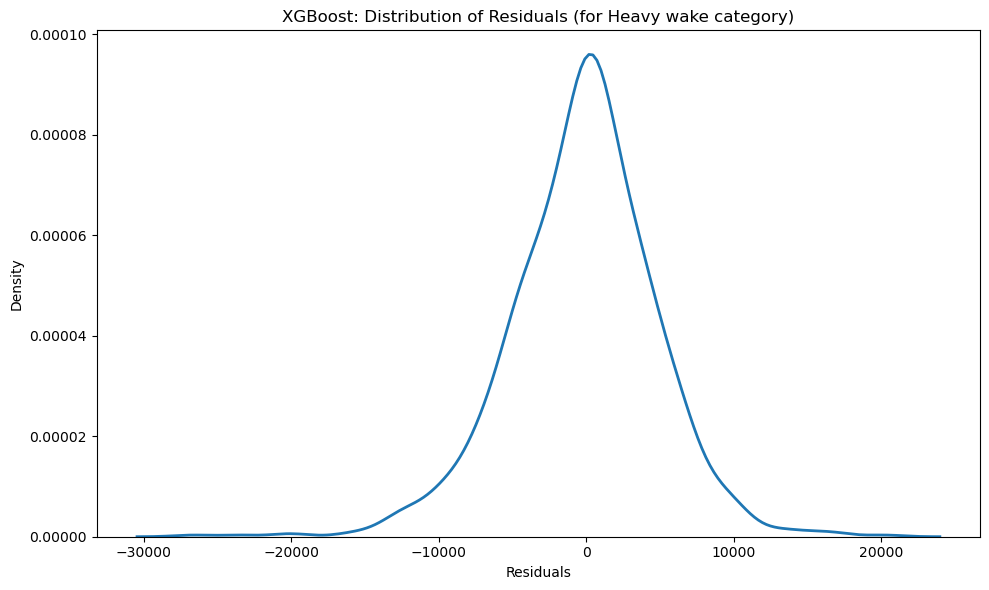

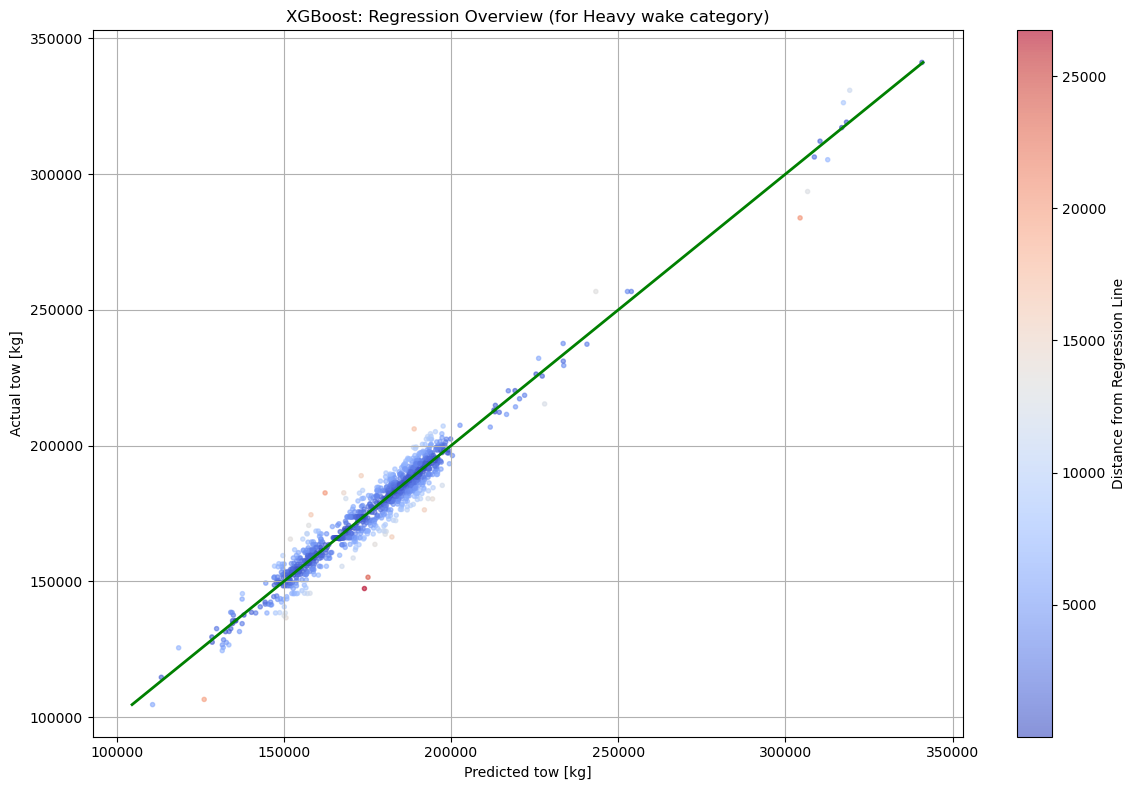

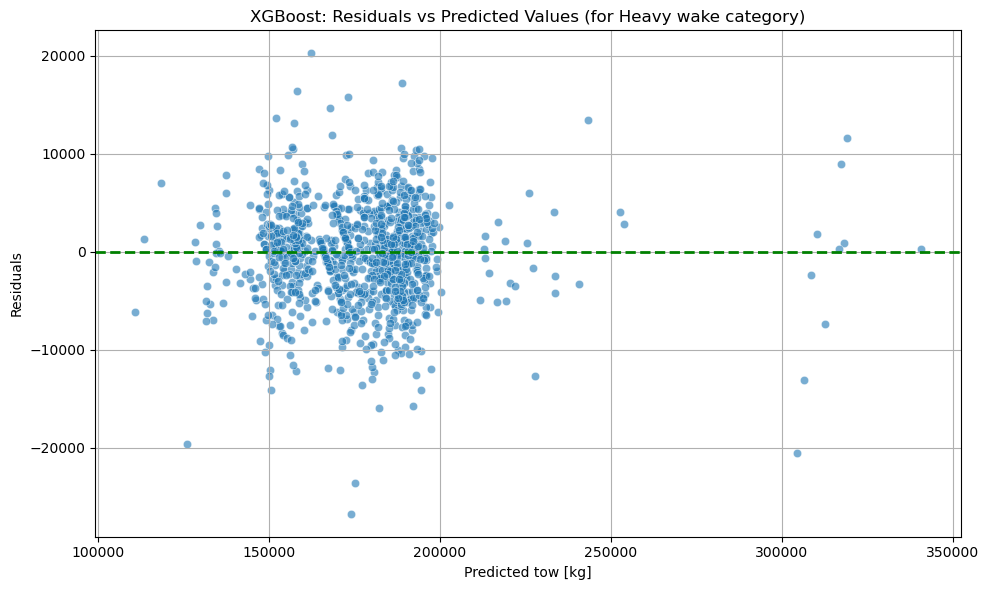

In [46]:
residuals = y_test - y_pred

title1 = "XGBoost: Distribution of Residuals (for Heavy wake category)"
title2 = "XGBoost: Regression Overview (for Heavy wake category)"
title3 = "XGBoost: Residuals vs Predicted Values (for Heavy wake category)"

path1 = "../reports/figures/H/xgboost_residuals_distribution.png"
path2 = "../reports/figures/H/xgboost_scatter.png"
path3 = "../reports/figures/H/xgboost_scatter_residuals.png"

get_model_figs(residuals, y_pred, y_test, title1, title2, title3, path1, path2, path3)